In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from itertools import product
import matplotlib.pyplot as plt

In [10]:
def Create_dataset():
    # define regression problem and generate synthetic data
    X = torch.arange(-1.5, 1.5, 0.05).view(-1, 1).type(torch.float32)
    Y = torch.sin(X*7.)*torch.exp(X)/7.

    return X, Y

In [ ]:
class MLP(torch.nn.Module):
    # constructor
    def __init__(self, input_size, hidden_sizes, output_size):
        super(MLP, self).__init__()

        self.layer = nn.ModuleList()
        self.layer.append(nn.Linear(input_size, hidden_sizes[0]))
        for i in range(len(hidden_sizes)-1):
            self.layer.append(nn.Linear(hidden_sizes[i], hidden_sizes[i+1]))
        self.layer.append(nn.Linear(hidden_sizes[-1], output_size))
        
        self.activation = nn.Tanh()
    # mathod called once the model is executed
    def forward(self, x):
        for i in range(len(self.layer)):
            x = self.layer[i](x)
            x = self.activation(x)
        return x

def TrainModel(N_epochs, model, X, Y, lr):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    MSE = nn.MSELoss()
    train_loss = []
    model.train()
    for _ in range(N_epochs):
        # this will zero out the gradients for this batch
        optimizer.zero_grad()
        # make predictions
        y_pred = model(X)
        # calculate the MSE loss
        loss = MSE(y_pred, Y)
        # backpropagate the loss
        loss.backward()
        # update the model weights (with assumed learning rate)
        optimizer.step()
        train_loss.append(loss.item())
    print("last loss value = ", train_loss[-1])
    print()
    plt.plot(range(1, len(train_loss) + 1), train_loss, label="Train loss")

    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.legend()
    plt.grid(True, which="both")
    plt.show()
    return train_loss, model

def TestModel(model, X, Y, show_plot=True):
    model.eval()
    MSE = nn.MSELoss()

    with torch.no_grad():
        Y_pred = model(X)

    if show_plot:
        plt.plot(X, Y, 'g')
        plt.plot(X, Y_pred, 'b')
        plt.show()

    return Y_pred

last loss value =  0.003922531846910715



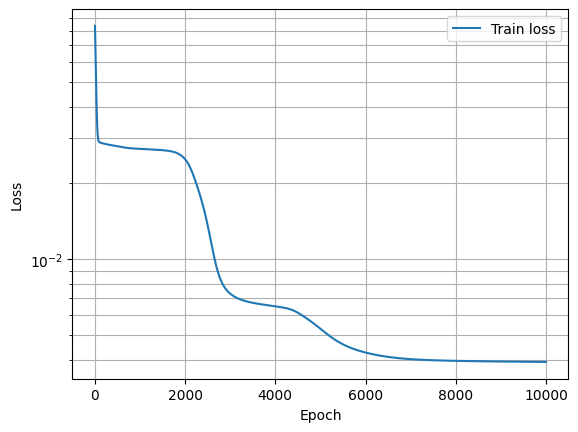

test loss =  0.003922504372894764


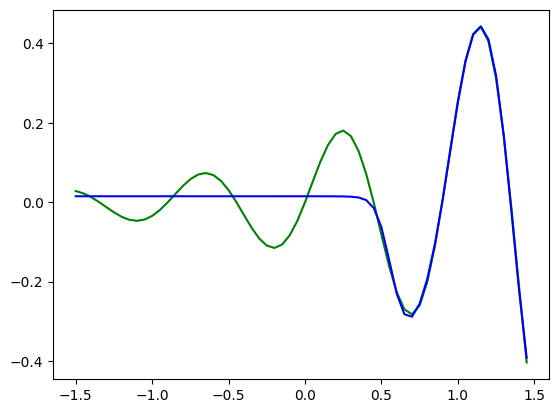

tensor([[ 0.0149],
        [ 0.0149],
        [ 0.0149],
        [ 0.0149],
        [ 0.0149],
        [ 0.0149],
        [ 0.0149],
        [ 0.0149],
        [ 0.0149],
        [ 0.0149],
        [ 0.0149],
        [ 0.0149],
        [ 0.0149],
        [ 0.0149],
        [ 0.0149],
        [ 0.0149],
        [ 0.0149],
        [ 0.0149],
        [ 0.0149],
        [ 0.0149],
        [ 0.0149],
        [ 0.0149],
        [ 0.0149],
        [ 0.0149],
        [ 0.0149],
        [ 0.0149],
        [ 0.0149],
        [ 0.0149],
        [ 0.0149],
        [ 0.0149],
        [ 0.0149],
        [ 0.0149],
        [ 0.0149],
        [ 0.0148],
        [ 0.0147],
        [ 0.0145],
        [ 0.0139],
        [ 0.0119],
        [ 0.0053],
        [-0.0148],
        [-0.0637],
        [-0.1452],
        [-0.2306],
        [-0.2824],
        [-0.2885],
        [-0.2559],
        [-0.1930],
        [-0.1046],
        [ 0.0053],
        [ 0.1288],
        [ 0.2516],
        [ 0.3548],
        [ 0.

In [12]:
X, Y = Create_dataset()
model = MLP(input_size=1, hidden_sizes=[2, 2, 2], output_size=1)

loss, model = TrainModel(10000, model, X, Y, 1e-3)

TestModel(model, X, Y)

last loss value =  4.188637376500992e-06



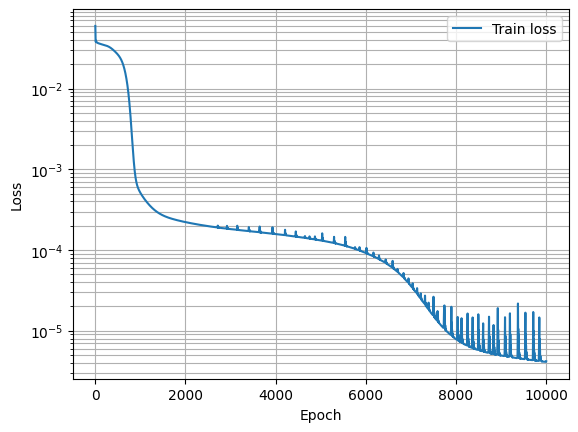

test loss =  0.0032304981723427773
last loss value =  8.132115908665583e-05



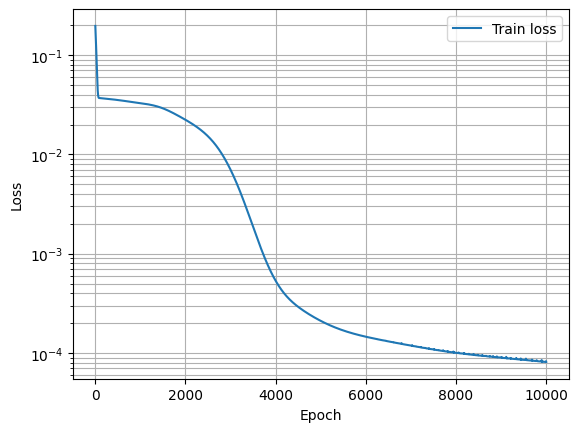

test loss =  0.0019055770244449377
last loss value =  1.768091351550538e-05



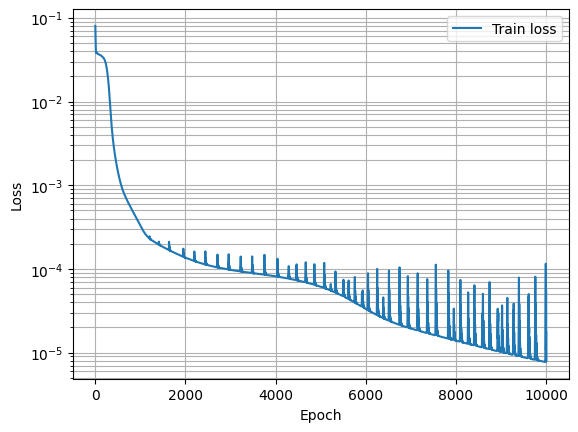

test loss =  0.008524751290678978


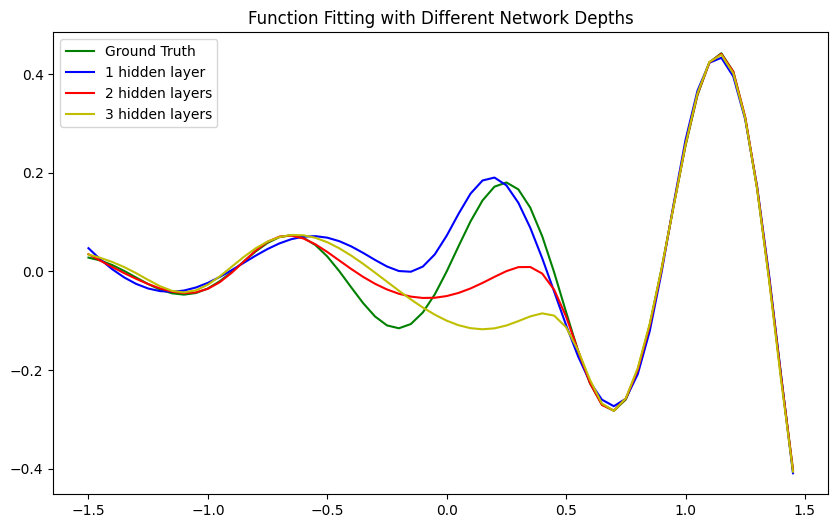

In [13]:
## zdanie 3 ##
def Create_dataset_with_gap(gap=(-0.5, 0.5)):
    X, Y = Create_dataset()

    mask = (X[:, 0] < gap[0]) | (X[:, 0] > gap[1])

    return X[mask], Y[mask]

X_train, Y_train = Create_dataset_with_gap()

model_2_16 = MLP(input_size=1, hidden_sizes=[16, 16], output_size=1)
loss_2_16, model_2_16 = TrainModel(10000, model_2_16, X_train, Y_train, 1e-3)
Y_pred_2_16 = TestModel(model_2_16, X, Y, 0)

model_1_16 = MLP(input_size=1, hidden_sizes=[16], output_size=1)
loss_1_16, model_1_16 = TrainModel(10000, model_1_16, X_train, Y_train, 1e-3)
Y_pred_1_16 = TestModel(model_1_16, X, Y, 0)

model_3_16 = MLP(input_size=1, hidden_sizes=[16, 16, 16], output_size=1)
loss_3_16, model_3_16 = TrainModel(10000, model_3_16, X_train, Y_train, 1e-3)
Y_pred_3_16 = TestModel(model_3_16, X, Y, 0)

plt.figure(figsize=(10, 6))
plt.plot(X, Y, 'g', label='Ground Truth')
plt.plot(X, Y_pred_1_16, 'b', label='1 hidden layer')
plt.plot(X, Y_pred_2_16, 'r', label='2 hidden layers')
plt.plot(X, Y_pred_3_16, 'y', label='3 hidden layers')
plt.title('Function Fitting with Different Network Depths')
plt.legend()
plt.show()



